In [2]:
import numpy as np

#EXERCISE 4
#Task 1
matrix =np.ones((5,5), dtype=int)
matrix[1:-1,1:-1]=0
print(matrix)


[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]


In [20]:
#Task 2
np.random.seed(42)
random_data = np.random.randn(100, 3)
column_means = random_data.mean(axis=0)
centered_data = random_data - column_means
column_stds = random_data.std(axis=0)
normalized_data = centered_data / column_stds

print(normalized_data.mean(axis=0))
print(normalized_data.std(axis=0))

[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
[1. 1. 1.]


In [4]:
#Task 3
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

X_transpose = X.T
XtX = X_transpose @ X
XtX_inv = np.linalg.inv(XtX)
Xty = X_transpose @ y
theta_hat = XtX_inv @ Xty
print("Estimated theta coefficients:", theta_hat)
print("True theta coefficients:", true_theta)

Estimated theta coefficients: [ 2.49289599 -1.18693519  3.69669127]
True theta coefficients: [ 2.5 -1.2  3.7]


In [6]:
#EXERCISE 5
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}



In [22]:
#Task 1
df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan


display(df.head())
df.info()

df.isnull().sum()

df['exam_score'] = df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean'))

df['hours_studied'] = df['hours_studied'].fillna(
    df.groupby('year')['hours_studied'].transform('median'))



,student_id,major,year,exam_score,assignments_completed,hours_studied
0,1000,Physics,3,68.199753,10,10.922505
1,1001,Biology,4,77.322537,9,12.204873
2,1002,CS,3,77.930725,9,7.829556
3,1003,Physics,1,67.856486,2,14.042336
4,1004,Physics,4,93.657745,6,15.287370


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB


In [14]:
#Task 2
avg_by_major = df.groupby('major')['exam_score'].mean()
print("Average exam score by major:")
print(avg_by_major)

top_major = avg_by_major.idxmax()
top_score = avg_by_major.max()

print(f"\nMajor with highest average exam score: {top_major}")
print(f"Average score: {top_score}")

correlation = df['hours_studied'].corr(df['exam_score'])

print("\nCorrelation between hours studied and exam score:")
print(correlation)

conditions = [
    df['exam_score'] > 90,
    (df['exam_score'] >= 80) & (df['exam_score'] <= 90),
    (df['exam_score'] >= 70) & (df['exam_score'] < 80),
    df['exam_score'] < 70
]

choices = ['Excellent', 'Good', 'Average', 'Needs Improvement']

df['performance'] = np.select(
    conditions, 
    choices,
    default ='Unknown')

df[['exam_score', 'performance']].head()

df['performance'].value_counts()

Average exam score by major:
major
Biology    75.652637
CS         76.463582
Math       74.819095
Physics    75.540895
Name: exam_score, dtype: float64

Major with highest average exam score: CS
Average score: 76.46358173059731

Correlation between hours studied and exam score:
-0.07217405122116978


performance
Average              81
Needs Improvement    56
Good                 51
Excellent            12
Name: count, dtype: int64

In [15]:
#Task 3

summary = df.groupby(['major', 'year']).agg(
    student_count=('exam_score', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).reset_index()

print(summary)

top_score_threshold = df['exam_score'].nlargest(5).min()

top_students = df[df['exam_score'] >= top_score_threshold]

print(top_students.sort_values('exam_score', ascending=False))

pivot = df.pivot_table(
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print(pivot)

      major  year  student_count  avg_exam_score  avg_hours_studied
0   Biology     1             13       76.570059          12.677806
1   Biology     2             12       75.085966          13.426372
2   Biology     3             14       80.595336          15.095221
3   Biology     4             15       70.697689          14.253944
4        CS     1             12       76.716704          13.039480
5        CS     2              7       76.155936          13.595825
6        CS     3              9       72.347626          15.039892
7        CS     4             18       78.472451          16.275541
8      Math     1             11       74.554794          19.001215
9      Math     2              9       82.669539          12.654613
10     Math     3             10       71.317493          15.175871
11     Math     4             16       72.773428          17.317643
12  Physics     1             13       76.810365          13.489911
13  Physics     2             12       73.887110

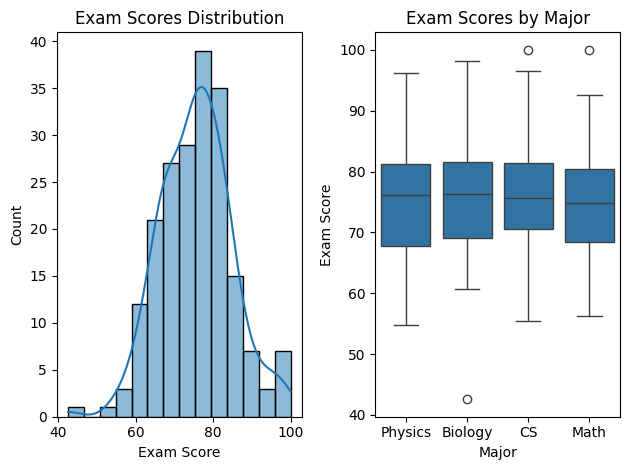

In [16]:
#EXERCISE 6
import matplotlib.pyplot as plt
import seaborn as sns

#Task 1

fig, axes = plt.subplots(1, 2)

sns.histplot(
    df['exam_score'],
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Exam Scores Distribution')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')

sns.boxplot(
    x='major',
    y='exam_score',
    data=df,
    ax=axes[1]
)

axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()


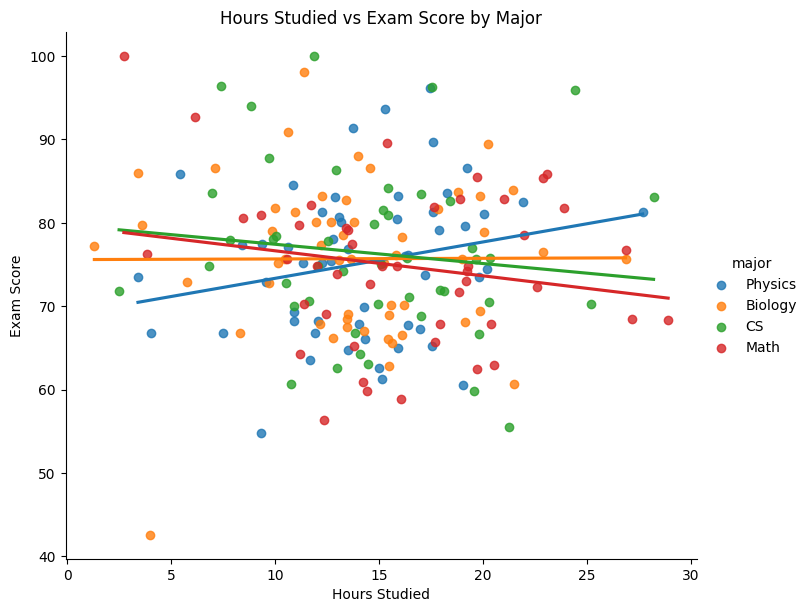

In [23]:
#Task 2

sns.lmplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',
    height=6,
    aspect=1.2,
    ci=None
)

plt.title('Hours Studied vs Exam Score by Major')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')

plt.show()

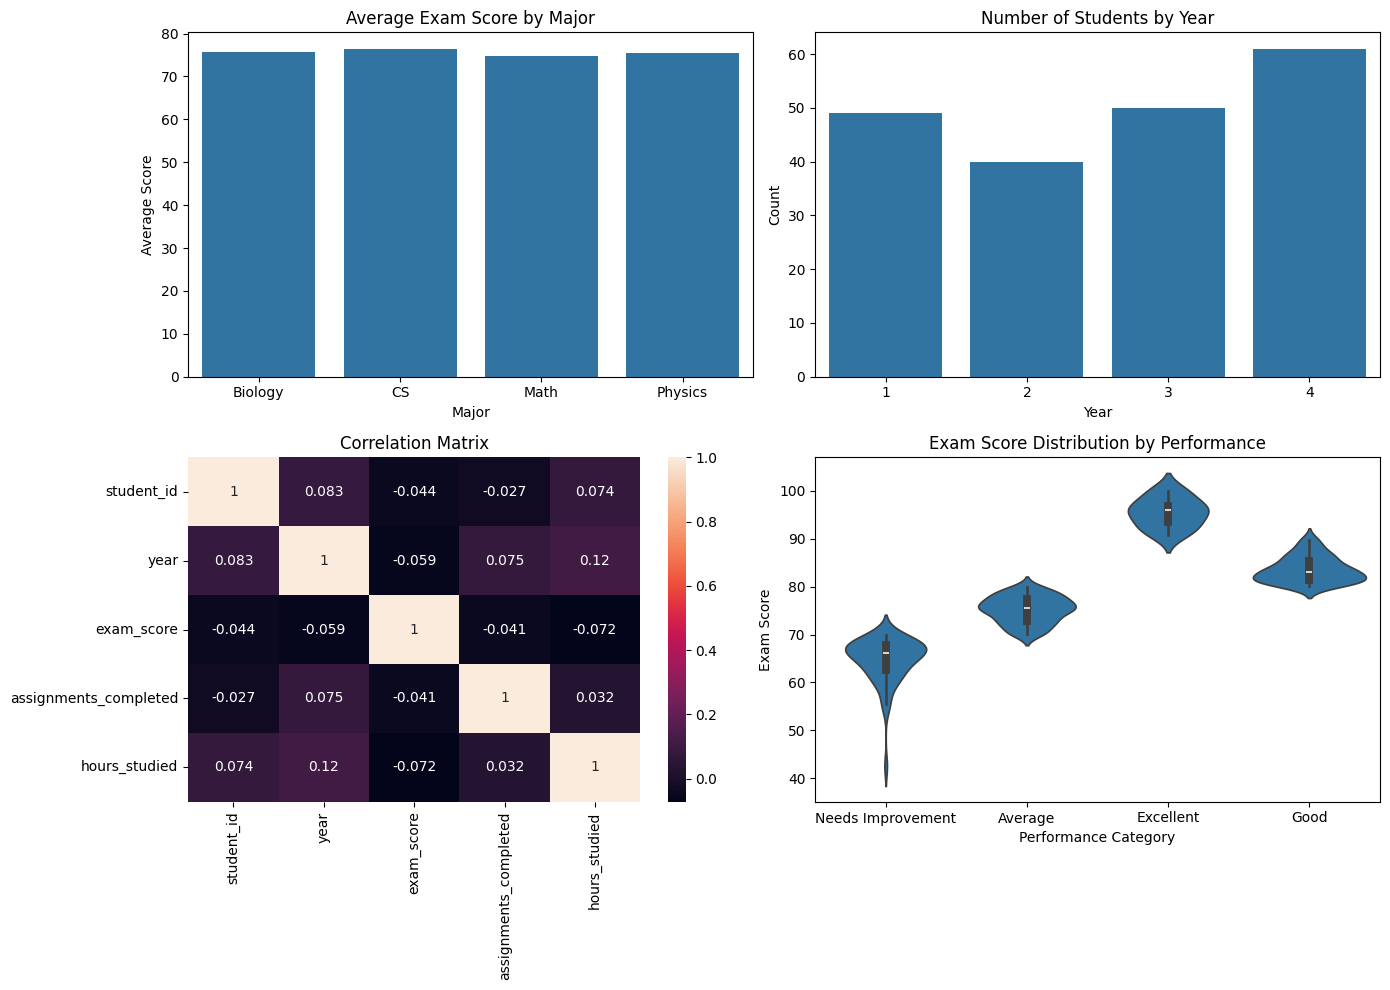

In [18]:
#Task 3

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
avg_major = df.groupby('major')['exam_score'].mean()

sns.barplot(
    x=avg_major.index,
    y=avg_major.values,
    ax=axes[0, 0]
)

axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')

sns.countplot(
    x='year',
    data=df,
    ax=axes[0, 1]
)

axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    ax=axes[1, 0]
)

axes[1, 0].set_title('Correlation Matrix')

sns.violinplot(
    x='performance',
    y='exam_score',
    data=df,
    ax=axes[1, 1]
)

axes[1, 1].set_title('Exam Score Distribution by Performance')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')

plt.tight_layout()

plt.show()

           customer_count    avg_income     avg_CLV      total_CLV
age_group                                                         
18-25                  81  50634.018330  718.371170   58188.064760
26-35                  73  48747.148046  747.738562   54584.915035
36-50                 160  48516.895668  732.796612  117247.457917
51-70                 186  50713.163384  762.693498  141860.990683
     age        income  purchase_frequency  avg_purchase_value          CLV  \
6     38  58876.388563                  10          110.331527  1287.201143   
9     40  48809.492879                  10          110.228581  1286.000108   
19    41  21282.756976                   8          119.651218  1276.279663   
24    38  53981.193911                   8          120.320786  1283.421714   
57    64  45956.146951                   7          135.470585  1343.416638   
60    25  66508.326980                   7          142.042870  1408.591795   
76    61  62482.396341                   7   

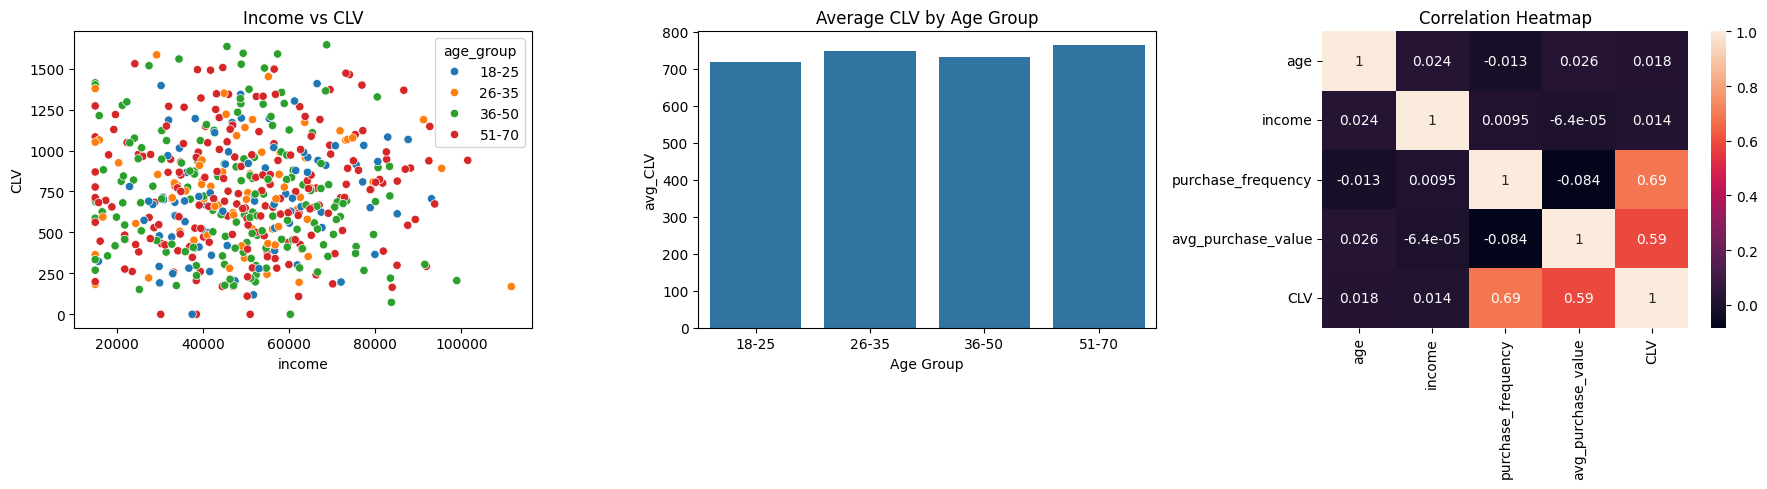

'From the customer dataset, a clear pattern emerges where purchase frequency plays a stronger role in driving customer lifetime value (CLV) \nthan income alone. This is evident because customers who make more frequent purchases consistently generate higher CLV, even when their income levels are moderate.\nThe age group analysis shows that customers in the 26–35 and 36–50 ranges contribute the highest overall and average CLV. This suggests that middle-aged customers \nare the most economically valuable segment, likely due to a balance of stable income and consistent purchasing behavior. In contrast, the 18–25 group shows lower \nCLV values, indicating either lower purchasing power or less consistent engagement with the platform. The top 10% CLV segment is dominated by customers with \nrelatively high purchase frequency rather than extremely high income, reinforcing the idea that engagement is more influential than wealth in this dataset. The \ncorrelation structure further supports this

In [ ]:
#EXERCISE 7

np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

max_frequency = customers['purchase_frequency'].max()

churn_risk = 1 - (customers['purchase_frequency'] / max_frequency)

customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + churn_risk)

bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']

customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, include_lowest=True)

age_summary = customers.groupby('age_group').agg(
    customer_count=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
)

print(age_summary)

threshold = customers['CLV'].quantile(0.90)

top_customers = customers[customers['CLV'] >= threshold]

print(top_customers)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group',
    ax=axes[0]
)

axes[0].set_title('Income vs CLV')

sns.barplot(
    x=age_summary.index,
    y=age_summary['avg_CLV'],
    ax=axes[1]
)

axes[1].set_title('Average CLV by Age Group')
axes[1].set_xlabel('Age Group')

sns.heatmap(
    customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr(),
    annot=True,
    ax=axes[2]
)

axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()




From the customer dataset, a clear pattern emerges where purchase frequency plays a stronger role in driving customer lifetime value (CLV) 
than income alone. This is evident because customers who make more frequent purchases consistently generate higher CLV, even when their income levels are moderate.
The age group analysis shows that customers in the 26–35 and 36–50 ranges contribute the highest overall and average CLV. This suggests that middle-aged customers 
are the most economically valuable segment, likely due to a balance of stable income and consistent purchasing behavior. In contrast, the 18–25 group shows lower 
CLV values, indicating either lower purchasing power or less consistent engagement with the platform. The top 10% CLV segment is dominated by customers with 
relatively high purchase frequency rather than extremely high income, reinforcing the idea that engagement is more influential than wealth in this dataset. The 
correlation structure further supports this interpretation, where purchase frequency has a noticeably stronger positive relationship with CLV compared to income 
or average purchase value

SUGGESTIONS
The company should prioritize retention strategies aimed at increasing purchase frequency, especially within the 26–50 age groups, as this segment provides the 
highest return. Additionally, targeted engagement campaigns for younger customers could help convert them into higher-value long-term users
